In [ ]:
!pip install gymnasium[atari] ale-py shimmy
!pip install -q "stable-baselines3[extra]" shimmy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 21.7 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import ale_py
from gymnasium.wrappers import (RecordVideo, AtariPreprocessing, FrameStackObservation)
import os, glob, time, shutil
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.atari_wrappers import AtariWrapper

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
NOM_ENTORNO = "ALE/SpaceInvaders-v5"
BASE_DIR = "/content/drive/MyDrive/Proyecto2/entregables"
VIDEO_FOLDER  = os.path.join(BASE_DIR, "videos")
VIDEO_FOLDER_ALEATORIO = os.path.join(BASE_DIR, "videos_aleatorio")
LOG_DIR = os.path.join(BASE_DIR, "logs")
BEST_DIR = os.path.join(BASE_DIR, "best_model")
FINAL_MODEL = os.path.join(BASE_DIR, "final_model")
ITER_DIR = os.path.join(BASE_DIR, "iteraciones")

for d in (VIDEO_FOLDER, VIDEO_FOLDER_ALEATORIO, LOG_DIR, BEST_DIR, FINAL_MODEL, ITER_DIR):
    os.makedirs(d, exist_ok=True)

print("Carpetas creadas")

Carpetas creadas


In [ ]:
def entorno(nom_entorno, video_folder=None, episode_trigger=None,
            name_prefix='SpaceInvaders_', render_mode=None, **kwargs):
    if video_folder is not None and render_mode is None:
        render_mode = "rgb_array"

    env = gym.make(nom_entorno, render_mode=render_mode, **kwargs)

    if video_folder is not None:
        os.makedirs(video_folder, exist_ok=True)
        if episode_trigger is None:
            episode_trigger = lambda ep: True
        env = RecordVideo(
            env,
            video_folder=video_folder,
            episode_trigger=episode_trigger,
            name_prefix=name_prefix,
        )
    return env

#random
"""
def baseline(observation, env):
  return env.action_space.sample()
"""

def episodio(env, func_agente, max_steps=5000, seed=None):
    observation, info = env.reset(seed=seed) if seed is not None else env.reset()

    recompensa_total = 0.0
    pasos = 0
    terminated = False
    truncated = False

    while not (terminated or truncated) and pasos < max_steps:
        action = func_agente(observation, env)
        observation, reward, terminated, truncated, info = env.step(action)
        recompensa_total += float(reward)
        pasos += 1

    return {
        "pasos": pasos,
        "recompensa_total": recompensa_total,
        "terminated": bool(terminated),
        "truncated": bool(truncated),
    }

def video(nom_entorno, func_agente, video_folder, name_prefix="Agente", n_episodios=1, max_steps=1000, seed=None, **env_kwargs):
  shutil.rmtree(video_folder, ignore_errors=True)
  os.makedirs(video_folder, exist_ok=True)

  env = entorno(
      nom_entorno,
      video_folder=video_folder,
      episode_trigger=lambda ep:True,
      name_prefix=name_prefix,
      render_mode="rgb_array",
      **env_kwargs,
  )

  metricas = []
  try:
      for i in range(n_episodios):
          ep_seed = None if seed is None else seed + i
          resultado = episodio(
              env, func_agente, max_steps=max_steps, seed=ep_seed
          )
          metricas.append(resultado)
  finally:
      env.close() #mp4

  videos = sorted(glob.glob(os.path.join(video_folder, f"{name_prefix}*.mp4")))
  return {"videos": videos, "metricas": metricas}

print("... Funciones bases listas ...")

... Funciones bases listas ...


In [ ]:
def crear_train_env(n_envs=4, seed=0):
    #VecEnv traingin con atarieapper sb3 y vecframstack 4
    vec_env = make_atari_env(
        NOM_ENTORNO, n_envs=n_envs, seed=seed,
        env_kwargs=dict(frameskip=1, repeat_action_probability=0.0, full_action_space=False),
        wrapper_kwargs=dict(screen_size=84, terminal_on_life_loss=True, clip_reward=True)
    )
    vec_env = VecFrameStack(vec_env, n_stack=4)
    return vec_env

def crear_eval_env(seed=0):
    #VecEnv eval (1 worker) == train pipeline
    vec_env = make_atari_env(NOM_ENTORNO, n_envs=1, seed=seed,
        env_kwargs=dict(frameskip=1, repeat_action_probability=0.0, full_action_space=False),
        wrapper_kwargs=dict(screen_size=84, terminal_on_life_loss=True, clip_reward=True)
    )
    vec_env = VecFrameStack(vec_env, n_stack=4)
    return vec_env

print("...Creadores de entornos listos ...")

...Creadores de entornos listos ...


In [ ]:
print("=== Callback ===")

def callbacks(eval_env, eval_freq=50_000, n_eval_episodes=5, best_dir=BEST_DIR, log_dir=LOG_DIR, ckpt_prefix="dqn"):
  eval_cb= EvalCallback(
      eval_env,
      best_model_save_path= best_dir,
      log_path = log_dir,
      eval_freq= eval_freq,
      n_eval_episodes=n_eval_episodes,
      deterministic=True,
      render=False
  )

  ckpt_cb = CheckpointCallback(save_freq=250_000, save_path=log_dir, name_prefix=ckpt_prefix)
  return [eval_cb, ckpt_cb]

print("... Callback listo ...\n")


print("=== MEJOR MODELO===")

def entrenar_modelo(total_timesteps=1_000_000, n_envs=4, seed=0, learning_rate=1e-4, buffer_size=200_000, learning_starts=20_000, batch_size=32, gamma=0.99, train_freq=4,
                    gradient_steps=1, target_update_interval=1_000, exploration_fraction=0.10, exploration_final_eps=0.01, tag="iter1"):

  iter_best  = os.path.join(ITER_DIR, tag, "best_model")
  iter_log   = os.path.join(ITER_DIR, tag, "logs")
  iter_final = os.path.join(ITER_DIR, tag, "final_model")
  for d in (iter_best, iter_log, iter_final):
      os.makedirs(d, exist_ok=True)

  train_env= crear_train_env(n_envs=n_envs, seed=seed)
  eval_env  = crear_eval_env(seed=seed + 100)

  modelo = DQN(
      "CnnPolicy",
      train_env,
      learning_rate= learning_rate,
      buffer_size = buffer_size,
      learning_starts = learning_starts,
      batch_size = batch_size,
      gamma = gamma,
      train_freq= train_freq,
      gradient_steps= gradient_steps,
      target_update_interval = target_update_interval,
      exploration_fraction = exploration_fraction,
      exploration_final_eps= exploration_final_eps,
      verbose=1,
      tensorboard_log= iter_log,
      seed=seed
  )

  modelo.learn(total_timesteps=total_timesteps,
               callback=callbacks(
                   eval_env, eval_freq=50_000, best_dir= iter_best,
                   log_dir= iter_log, ckpt_prefix= f"dqn_{tag}"
               ))
  ruta_final = os.path.join(iter_final, "dqn_final.zip")
  modelo.save(os.path.join(iter_final, "dqn_final"))

  train_env.close()
  eval_env.close()

  ruta_mejor = os.path.join(iter_best, "best_model.zip")

  if not os.path.exists(ruta_mejor):
      print(f"No se genero zip en {iter_best}, usando final...")
      ruta_mejor = ruta_final
  print(f"Iteracion: '{tag}' terminada.")
  print(f" - Mejor: {ruta_mejor}")
  print(f" - Final: {ruta_final}")
  return ruta_mejor, ruta_final

print("...Entrenamiento listo...")


=== Callback ===
... Callback listo ...

=== MEJOR MODELO===
...Entrenamiento listo...


In [ ]:
#ITERAACION 1 DQN BASELINE
print("=== ITERACIONES ===")

print("\n --- DQN BASELINE ---")
MEJOR_1, FINAL_1 = entrenar_modelo(
    total_timesteps=300_000,
    n_envs=3, seed=0,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=20_000,
    batch_size=32,
    train_freq=4, gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.10,
    exploration_final_eps=0.01,
    tag="iter1_baseline"
)

=== ITERACIONES ===

 --- DQN BASELINE ---
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter1_baseline/logs/DQN_1


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7c16a7782e40> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7c16a40bd370>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Streaming output truncated to the last 5000 lines.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.04e+03 |
|    ep_rew_mean      | 145      |
|    exploration_rate | 0.302    |
| time/               |          |
|    episodes         | 124      |
|    fps              | 641      |
|    time_elapsed     | 32       |
|    total_timesteps  | 21147    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000433 |
|    n_updates        | 96       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.04e+03 |
|    ep_rew_mean      | 145      |
|    exploration_rate | 0.267    |
| time/               |          |
|    episodes         | 128      |
|    fps              | 619      |
|    time_elapsed     | 35       |
|    total_timesteps  | 22221    |
| train/              |          |
|    learning_rate    | 0.0001   |
|   

In [ ]:
#ITERACION 2 +BUFFER, -EXPLO
print("\n --- ITERACION 2 ---")
MEJOR_2, FINAL_2 = entrenar_modelo(
    total_timesteps=600_000,
    n_envs=2, seed=0,
    learning_rate=1e-4,
    buffer_size=150_000, #+memoria
    learning_starts=20_000, #+warmup
    batch_size=32,
    train_freq=4, gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.05, #-tiempo exp.
    exploration_final_eps=0.01,
    tag="iter2"
)


 --- ITERACION 2 ---
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter2/logs/DQN_1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7ccbc1f8d400> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7ccbc1f84910>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Streaming output truncated to the last 5000 lines.
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.39e+03 |
|    ep_rew_mean      | 226      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 1552     |
|    fps              | 348      |
|    time_elapsed     | 949      |
|    total_timesteps  | 331202   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00428  |
|    n_updates        | 38900    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.36e+03 |
|    ep_rew_mean      | 225      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 1556     |
|    fps              | 349      |
|    time_elapsed     | 950      |
|    total_timesteps  | 331746   |
| train/              |          |
|   

In [ ]:
#ITERACION 3 TARG. UP. +VEL Y +BATCH
print("\n --- ITERACION 3 ---")
MEJOR_3, FINAL_3 = entrenar_modelo(
    total_timesteps=2_000_000,
    n_envs=2, seed=1,
    learning_rate=1e-4, #-lr fine-tuning
    buffer_size=80_000,
    learning_starts=20_000,
    batch_size=64, #+batch
    train_freq=4, gradient_steps=1,
    target_update_interval=1_000, #+agilidad target
    exploration_fraction=0.10,
    exploration_final_eps=0.01,
    tag="iter3"
)


 --- ITERACION 3 ---
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter3/logs/DQN_1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7d602c631400> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7d602c638910>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00856  |
|    n_updates        | 170633   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.27e+03 |
|    ep_rew_mean      | 665      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 5164     |
|    fps              | 330      |
|    time_elapsed     | 4193     |
|    total_timesteps  | 1386158  |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0222   |
|    n_updates        | 170769   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.32e+03 |
|    ep_rew_mean      | 677      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 5168     |
|   

In [ ]:
print("=== EVALUACION MODELO ===")

def evaluar_modelo(ruta_modelo, n_episodios=5, max_steps=5000, seed=42):
    def make():
        env = gym.make(NOM_ENTORNO, render_mode=None, frameskip=1, repeat_action_probability=0.0, full_action_space=False)
        env = AtariWrapper(env, screen_size=84, terminal_on_life_loss=True, clip_reward=False)  #ver puntaje
        return env

    vec_env = VecFrameStack(DummyVecEnv([make]), n_stack=4)
    model = DQN.load(ruta_modelo)

    metricas = []
    for i in range(n_episodios):
        vec_env.seed(seed + i)
        obs = vec_env.reset()
        total_r, pasos = 0.0, 0
        done = False
        while not done and pasos < max_steps:
            action, _ = model.predict(obs, deterministic=True)
            obs, rewards, dones, infos = vec_env.step(action)
            total_r += float(rewards[0])
            pasos += 1
            done = bool(dones[0])
        metricas.append({"episodio": i, "seed": seed + i,
                         "pasos": pasos, "recompensa_total": total_r})
    vec_env.close()

    recompensas = [m["recompensa_total"] for m in metricas]
    mejor = max(metricas, key=lambda m: m["recompensa_total"])
    return {
        "metricas": metricas,
        "promedio": float(np.mean(recompensas)),
        "mejor": mejor,
    }


print("--- EVALUACION ITERACIONES ---")

rutas = {
    "iter1_baseline":   os.path.join(ITER_DIR, "iter1_baseline",   "best_model", "best_model.zip"),
    "iter2": os.path.join(ITER_DIR, "iter2", "best_model", "best_model.zip"),
    "iter3":  os.path.join(ITER_DIR, "iter3",  "best_model", "best_model.zip"),
}

for tag, ruta in rutas.items():
    existe = os.path.exists(ruta)
    print(f"{'✅' if existe else 'ERROR'} {tag}: {ruta}")

resultados_eval = {}
for tag, ruta in rutas.items():
    if not os.path.exists(ruta):
        print(f"\n Saltando {tag}: no existe el .zip")
        continue
    print(f"\n + {tag}")
    r = evaluar_modelo(ruta, n_episodios=5, seed=42)
    resultados_eval[tag] = r
    for m in r["metricas"]:
        print(f"  Ep {m['episodio']}: pasos={m['pasos']}, R={m['recompensa_total']:.0f}")
    print(f"   promedio = {r['promedio']:.1f}, mejor = {r['mejor']['recompensa_total']:.0f}")

=== EVALUACION MODELO ===
--- EVALUACION ITERACIONES ---
✅ iter1_baseline: /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter1_baseline/best_model/best_model.zip
✅ iter2: /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter2/best_model/best_model.zip
✅ iter3: /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter3/best_model/best_model.zip

 + iter1_baseline
  Ep 0: pasos=184, R=105
  Ep 1: pasos=386, R=105
  Ep 2: pasos=139, R=75
  Ep 3: pasos=176, R=105
  Ep 4: pasos=386, R=105
   promedio = 99.0, mejor = 105

 + iter2


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 8.47GB > 6.13GB
  warnings.warn(


  Ep 0: pasos=291, R=100
  Ep 1: pasos=266, R=135
  Ep 2: pasos=58, R=0
  Ep 3: pasos=508, R=340
  Ep 4: pasos=261, R=35
   promedio = 122.0, mejor = 340

 + iter3
  Ep 0: pasos=789, R=570
  Ep 1: pasos=970, R=545
  Ep 2: pasos=786, R=600
  Ep 3: pasos=223, R=120
  Ep 4: pasos=648, R=685
   promedio = 504.0, mejor = 685


In [ ]:
print("=== RESULTADOS ===")

mejor_tag = max(resultados_eval, key=lambda k: resultados_eval[k]["promedio"])
MEJOR_MODELO = rutas[mejor_tag]
print(f"Mejor iteracion: {mejor_tag}")
print(f" - promedio = {resultados_eval[mejor_tag]['promedio']:.1f}")
print(f" - maximo   = {resultados_eval[mejor_tag]['mejor']['recompensa_total']:.0f}")
print(f" - modelo   = {MEJOR_MODELO}")

with open(os.path.join(BASE_DIR, "resultados_iteraciones.json"), "w") as f:
    json.dump({k: {"promedio": v["promedio"],
                   "mejor": v["mejor"]["recompensa_total"],
                   "metricas": v["metricas"]}
               for k, v in resultados_eval.items()}, f, indent=2)
print("Resultados guardados en resultados_iteraciones.json")

=== RESULTADOS ===
Mejor iteracion: iter3
 - promedio = 504.0
 - maximo   = 685
 - modelo   = /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter3/best_model/best_model.zip
Resultados guardados en resultados_iteraciones.json


In [ ]:
#VIDEO
print("=== GRABACION VIDEO ===")
def eval_grabar(ruta_modelo, video_folder=VIDEO_FOLDER, name_prefix="spaceinvaders_dqn", n_episodios=5, max_steps=5000, seed=42):

    shutil.rmtree(video_folder, ignore_errors=True)
    os.makedirs(video_folder, exist_ok=True)

    def _make():
        env = gym.make(NOM_ENTORNO, render_mode="rgb_array", frameskip=1, repeat_action_probability=0.0, full_action_space=False)
        env = AtariWrapper(env, screen_size=84, terminal_on_life_loss=True, clip_reward=False)
        env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda ep: True, name_prefix=name_prefix)
        return env

    vec_env = VecFrameStack(DummyVecEnv([_make]), n_stack=4)
    print("Observation space modelo:", vec_env.observation_space)

    model = DQN.load(ruta_modelo)

    metricas = []
    mejor_puntaje = -float("inf")
    mejor_pasos = 0
    mejor_episodio = None

    try:
        for i in range(n_episodios):
            vec_env.seed(seed + i)
            obs = vec_env.reset()
            total_r, pasos = 0.0, 0
            done = False
            while not done and pasos < max_steps:
                action, _ = model.predict(obs, deterministic=True)
                obs, rewards, dones, infos = vec_env.step(action)
                total_r += float(rewards[0])
                pasos += 1
                done = bool(dones[0])
            metricas.append({"episodio": i, "pasos": pasos,
                             "recompensa_total": total_r,
                             "seed": seed + i})
            if total_r > mejor_puntaje:
                mejor_puntaje = total_r
                mejor_pasos = pasos
                mejor_episodio = i
    finally:
        vec_env.close()#mp4

    videos = sorted(glob.glob(os.path.join(video_folder, f"{name_prefix}*.mp4")))
    promedio = float(np.mean([m["recompensa_total"] for m in metricas]))

    mejor_video = None
    if mejor_episodio is not None and mejor_episodio < len(videos):
        ruta_original = videos[mejor_episodio]
        nuevo_nombre = os.path.join(
            video_folder,
            f"MEJOR_ep{mejor_episodio}_R{int(mejor_puntaje)}_pasos{mejor_pasos}.mp4"
        )
        os.rename(ruta_original, nuevo_nombre)
        mejor_video = nuevo_nombre
        print(f"-- Video del mejor renombrado a: {os.path.basename(nuevo_nombre)}")

    return {
        "videos": videos,
        "metricas": metricas,
        "mejor_puntaje": mejor_puntaje,
        "mejor_pasos": mejor_pasos,
        "mejor_episodio_idx": mejor_episodio,
        "promedio": promedio,
        "mejor_video": mejor_video
    }


print("=== RESULTADOS FINALES ===")
resultado = eval_grabar(MEJOR_MODELO, n_episodios=5, seed=42, max_steps=5000)

print("\nVideos guardados:")
for v in resultado["videos"]:
    print("  -", v)

print("\nMetricas por episodio:")
for m in resultado["metricas"]:
    print(f"  Ep {m['episodio']}: pasos={m['pasos']}, R={m['recompensa_total']:.0f}")

print(f"MAXIMO PUNTAJE:  {resultado['mejor_puntaje']:.0f}")
print(f"   (episodio {resultado['mejor_episodio_idx']}, {resultado['mejor_pasos']} pasos)")
print(f"\t Puntaje promedio: {resultado['promedio']:.1f}")
print(f"\n\t- Video del mejor episodio: {resultado['mejor_video']}")

=== GRABACION VIDEO ===
=== RESULTADOS FINALES ===
Observation space modelo: Box(0, 255, (84, 84, 4), uint8)


/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/Proyecto2/entregables/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


-- Video del mejor renombrado a: MEJOR_ep4_R685_pasos648.mp4

Videos guardados:
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-0.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-1.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-2.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-3.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-4.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-5.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-6.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-7.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-8.mp4
  - /content/drive/MyDrive/Proyecto2/entregables/videos/spaceinvaders_dqn-episode-9.mp4

Metricas por episodio:
  Ep 0: pasos=78

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


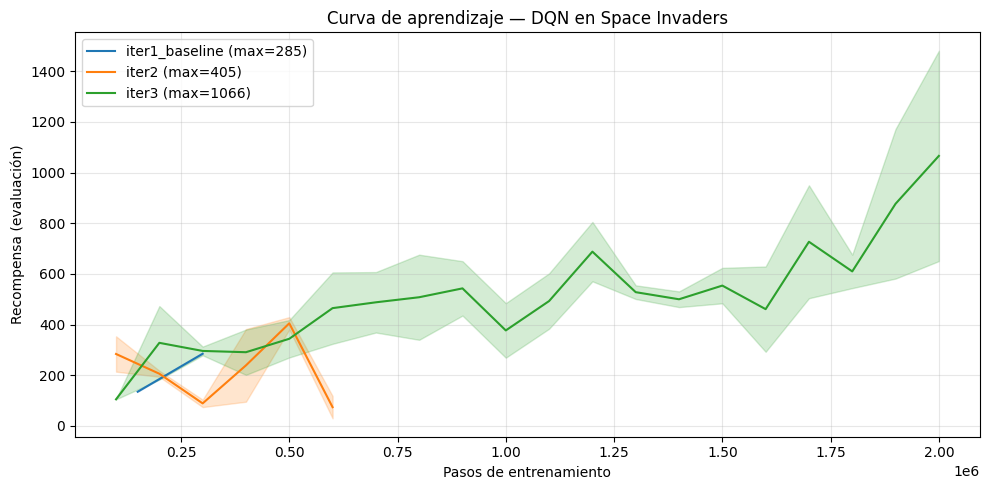

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {"iter1_baseline": "tab:blue",
           "iter2": "tab:orange",
           "iter3": "tab:green"}

for tag, color in colores.items():
    path = os.path.join(ITER_DIR, tag, "logs", "evaluations.npz")
    if not os.path.exists(path):
        print(f" No existe {path}")
        continue
    data = np.load(path)
    recompensas = data["results"]
    timesteps = data["timesteps"]
    media = recompensas.mean(axis=1)
    std = recompensas.std(axis=1)
    ax.plot(timesteps, media, label=f"{tag} (max={media.max():.0f})", color=color)
    ax.fill_between(timesteps, media - std, media + std, alpha=0.2, color=color)

ax.set_xlabel("Pasos de entrenamiento")
ax.set_ylabel("Recompensa (evaluación)")
ax.set_title("Curva de aprendizaje — DQN en Space Invaders")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
filas = []
for tag, r in resultados_eval.items():
    filas.append({
        "iteración": tag,
        "promedio": r["promedio"],
        "máximo": r["mejor"]["recompensa_total"],
        "mejor_pasos": r["mejor"]["pasos"],
    })
df = pd.DataFrame(filas).sort_values("promedio", ascending=False)
print(df.to_string(index=False))

# Guardar para el README
df.to_csv(os.path.join(BASE_DIR, "tabla_iteraciones.csv"), index=False)
print("\nGuardado en tabla_iteraciones.csv")

     iteración  promedio  máximo  mejor_pasos
         iter3     504.0   685.0          648
         iter2     122.0   340.0          508
iter1_baseline      99.0   105.0          184

Guardado en tabla_iteraciones.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# COMPETENCIA

In [ ]:
!pip install -q "gymnasium[atari]" ale-py "stable-baselines3[extra]" shimmy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os, glob
import numpy as np
import gymnasium as gym
import ale_py
from google.colab import drive
drive.mount('/content/drive')

from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

NOM_ENTORNO = "ALE/SpaceInvaders-v5"
ITER_DIR    = "/content/drive/MyDrive/Proyecto2/entregables/iteraciones"

RUTA_MODELO = os.path.join(ITER_DIR, "iter3", "best_model", "best_model.zip")
print(f"Modelo: {RUTA_MODELO}")
assert os.path.exists(RUTA_MODELO), "No existe el modelo, verificar ruta"

def _make():
    env = gym.make(NOM_ENTORNO, render_mode=None, frameskip=1,
                   repeat_action_probability=0.0, full_action_space=False)
    env = AtariWrapper(env, screen_size=84,
                       terminal_on_life_loss=True, clip_reward=False)
    return env

vec_env = VecFrameStack(DummyVecEnv([_make]), n_stack=4)
model = DQN.load(RUTA_MODELO)

#greedy
puntajes = []
for i in range(5):
    vec_env.seed(42 + i)
    obs = vec_env.reset()
    total_r, pasos, done = 0.0, 0, False
    while not done and pasos < 5000:
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, _ = vec_env.step(action)
        total_r += float(rewards[0]); pasos += 1
        done = bool(dones[0])
    puntajes.append(total_r)
    print(f"  Ep {i}: R = {total_r:.0f} ({pasos} pasos)")

vec_env.close()

print("\nRESULTADOS")
print("="*50)
print(f"  Promedio: {np.mean(puntajes):.1f}")
print(f"  Max puntaje : {max(puntajes):.0f}")
print(f"  Todos   : {[int(p) for p in puntajes]}")
print("="*50)

Mounted at /content/drive


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Modelo: /content/drive/MyDrive/Proyecto2/entregables/iteraciones/iter3/best_model/best_model.zip


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Ep 0: R = 570 (789 pasos)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Ep 1: R = 545 (970 pasos)
  Ep 2: R = 600 (786 pasos)
  Ep 3: R = 120 (223 pasos)
  Ep 4: R = 685 (648 pasos)

RESULTADOS
  Promedio: 504.0
  Max puntaje : 685
  Todos   : [570, 545, 600, 120, 685]
